In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
tf_fimo = pd.read_csv("fimo.tsv", sep="\t")
tf_fimo[['TE_family', 'TE_superfamily']] = tf_fimo['sequence_name'].str.split('#', expand=True)
tf_fimo.head()

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence,TE_family,TE_superfamily
0,MA0533.1,su(Hw),nf_95_I_1#LINE/I,749.0,769.0,+,28.0816,2.380000e-12,0.000008,gcccaaaagtatgcaacaatt,nf_95_I_1,LINE/I
1,MA2316.2,l(3)neo38,nf_9_MAVERICK_1#DNA/Maverick,231.0,248.0,+,24.7394,1.870000e-09,0.006730,ccctcccctccccctccc,nf_9_MAVERICK_1,DNA/Maverick
2,MA0533.1,su(Hw),nf_381_TIR_1#DNA/DNA,35.0,55.0,+,23.8673,2.120000e-09,0.003650,gtctaaaagtatgcaacaata,nf_381_TIR_1,DNA/DNA
3,MA2316.2,l(3)neo38,nf_9_MAVERICK_1#DNA/Maverick,69.0,86.0,+,22.3521,1.410000e-08,0.014400,actccccctcccactccc,nf_9_MAVERICK_1,DNA/Maverick
4,MA2316.2,l(3)neo38,nf_3_MAVERICK_1#DNA/Maverick,27.0,44.0,+,22.2042,1.600000e-08,0.014400,gccccccctcccccctca,nf_3_MAVERICK_1,DNA/Maverick


In [4]:
tf_fimo_filtered = tf_fimo[tf_fimo["q-value"] < 0.05].copy()
tf_fimo_filtered.head()

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence,TE_family,TE_superfamily
0,MA0533.1,su(Hw),nf_95_I_1#LINE/I,749.0,769.0,+,28.0816,2.380000e-12,0.000008,gcccaaaagtatgcaacaatt,nf_95_I_1,LINE/I
1,MA2316.2,l(3)neo38,nf_9_MAVERICK_1#DNA/Maverick,231.0,248.0,+,24.7394,1.870000e-09,0.006730,ccctcccctccccctccc,nf_9_MAVERICK_1,DNA/Maverick
2,MA0533.1,su(Hw),nf_381_TIR_1#DNA/DNA,35.0,55.0,+,23.8673,2.120000e-09,0.003650,gtctaaaagtatgcaacaata,nf_381_TIR_1,DNA/DNA
3,MA2316.2,l(3)neo38,nf_9_MAVERICK_1#DNA/Maverick,69.0,86.0,+,22.3521,1.410000e-08,0.014400,actccccctcccactccc,nf_9_MAVERICK_1,DNA/Maverick
4,MA2316.2,l(3)neo38,nf_3_MAVERICK_1#DNA/Maverick,27.0,44.0,+,22.2042,1.600000e-08,0.014400,gccccccctcccccctca,nf_3_MAVERICK_1,DNA/Maverick


In [5]:
tf_fimo_filtered.shape

(172, 12)

In [6]:
motifs_superfamilies_df = tf_fimo_filtered[['motif_id','motif_alt_id', 'TE_superfamily']]
motifs_superfamilies_df.to_csv('motifs_by_te_superfamily.tsv', sep='\t', index=False)

In [7]:
TE_family_counts = tf_fimo_filtered['TE_family'].value_counts()
TE_superfamily_counts = tf_fimo_filtered['TE_superfamily'].value_counts()
motifs_counts = tf_fimo_filtered['motif_alt_id'].value_counts()

print(TE_family_counts, TE_superfamily_counts, motifs_counts)

TE_family
Gypsy-16_DWil-LTR_inc_1    18
nf_11_MAVERICK_1           16
nf_9_MAVERICK_1            13
nf_9_MAVERICK_2            10
nf_30_GYPSY_1               6
                           ..
nf_100_I_1                  1
nf_119_I_2                  1
nf_106_GYPSY_1              1
nf_132_GYPSY_1              1
Jockey-2_DK                 1
Name: count, Length: 72, dtype: int64 TE_superfamily
LTR/GYPSY       49
DNA/Maverick    46
LINE/I          30
LTR/BELPAO      12
LTR/COPIA        8
LINE/JOCKEY      5
RC/Helitron      4
LINE/R1          4
DNA/MITE         3
LTR/LTR          2
DNA/DNA          2
LINE/CR1         2
DNA/TRANSIB      2
DNA/HAT          1
DNA/CMC          1
DNA/PIGGYBAC     1
Name: count, dtype: int64 motif_alt_id
cg           83
CG4360       39
CG3065       23
l(3)neo38    21
su(Hw)        4
Rfx           2
Name: count, dtype: int64


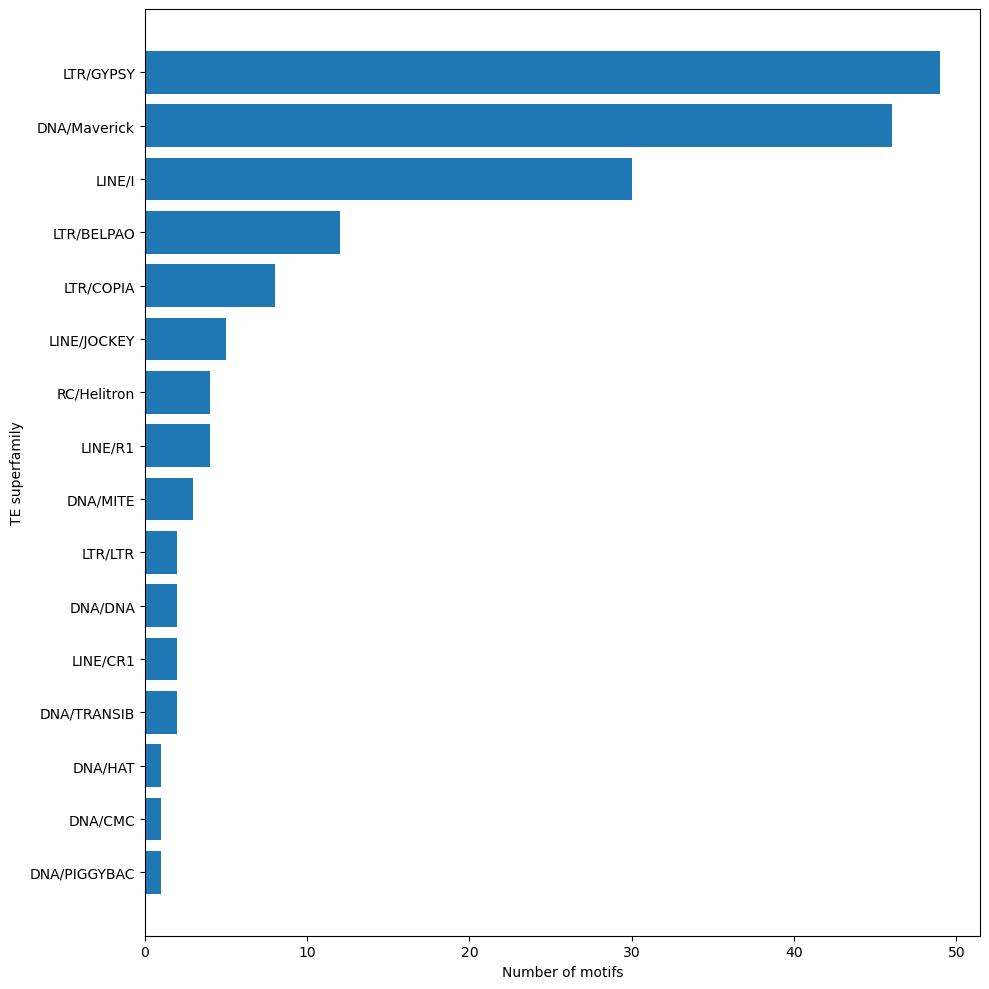

In [8]:
plt.figure(figsize=(10,10))
plt.barh(TE_superfamily_counts.index, TE_superfamily_counts.values)
plt.xlabel("Number of motifs")
plt.ylabel('TE superfamily')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("mottifs_per_TE.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
table = pd.crosstab(tf_fimo_filtered['TE_superfamily'], tf_fimo_filtered['motif_alt_id'])
table["total"] = table.sum(axis=1)
table.sort_values(by='total', ascending=True, inplace=True)
table = table.drop(columns=['total'])

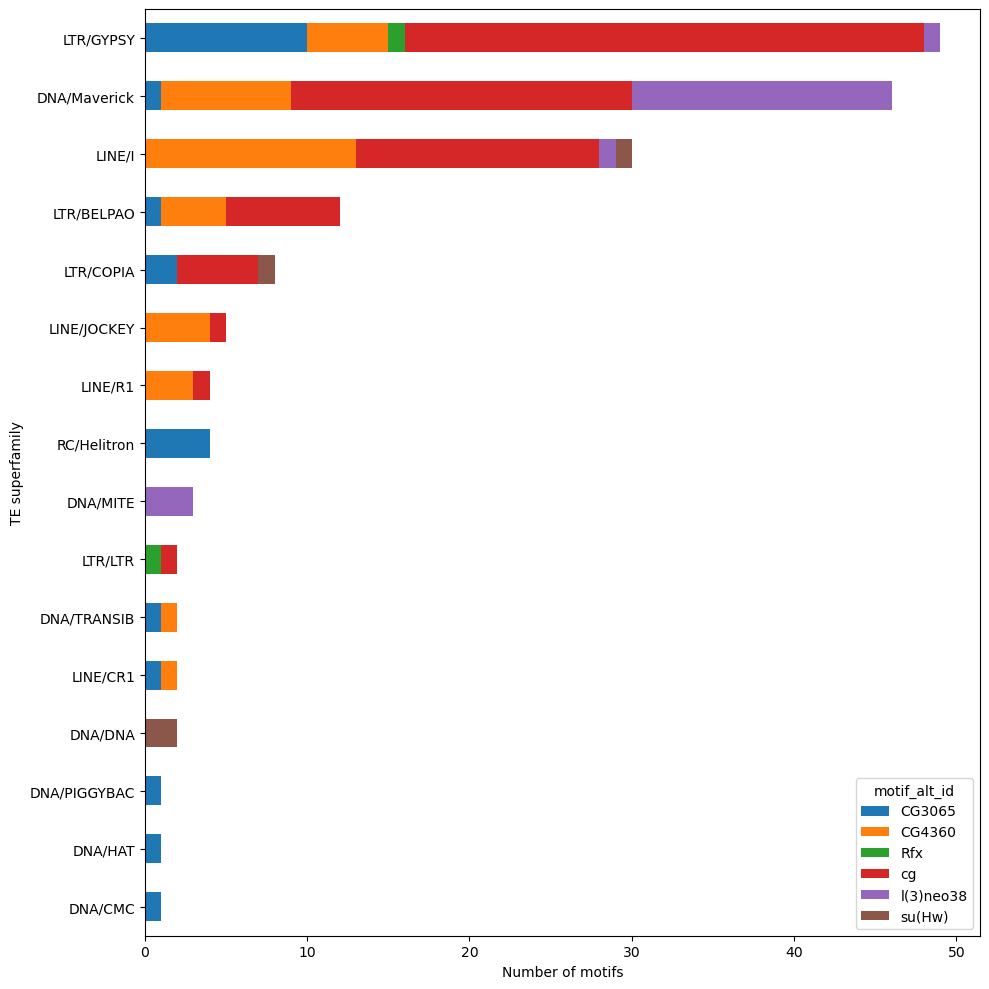

In [11]:
table.plot(kind='barh', stacked=True, figsize=(10,10))
plt.xlabel("Number of motifs")
plt.ylabel("TE superfamily")
plt.tight_layout()
plt.savefig("motif_id_per_TE.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()